<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/ClusterAglomerativo_Ejer1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
# 1. Definir los datos
X = np.array([
    [1, 1],   # A (Índice 0)
    [2, 1],   # B (Índice 1)
    [5, 5],   # C (Índice 2)
    [6, 5],   # D (Índice 3)
    [10,10],  # E (Índice 4)
    [11,10]   # F (Índice 5)
])
etiquetas = ['A', 'B', 'C', 'D', 'E', 'F']

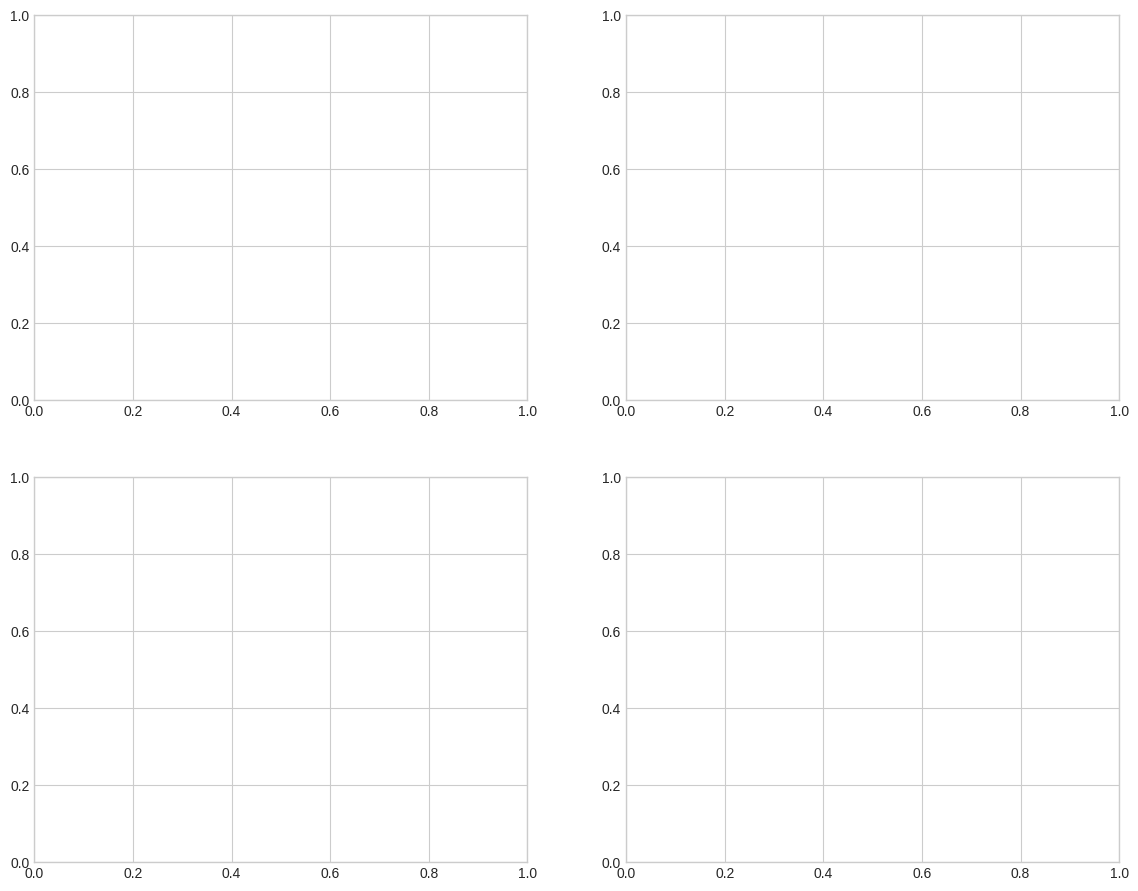

In [3]:
# Configuración de estilo para las gráficas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axs = plt.subplots(2, 2, figsize=(14, 11))

In [5]:
# --- ACTIVIDAD 1: Graficar los datos antes del clustering ---
axs[0, 0].scatter(X[:, 0], X[:, 1], color='slategray', s=150, zorder=3)
for i, txt in enumerate(etiquetas):
    axs[0, 0].annotate(txt, (X[i, 0], X[i, 1]), xytext=(7, 7), textcoords='offset points', fontsize=12, fontweight='bold')
axs[0, 0].set_title("1. Datos Originales (Antes del Clustering)", fontsize=13, pad=10)
axs[0, 0].set_xlim(0, 13)
axs[0, 0].set_ylim(0, 13)

(0.0, 13.0)

In [6]:
# --- ACTIVIDAD 2: Aplicar clustering jerárquico aglomerativo ---
# 'ward' minimiza la varianza dentro de los clusters que se van uniendo
Z = linkage(X, method='ward')

In [7]:
# --- ACTIVIDAD 3: Generar el dendrograma ---
dendrogram(Z, labels=etiquetas, ax=axs[0, 1], color_threshold=0)
axs[0, 1].set_title("2. Dendrograma Completo", fontsize=13, pad=10)
axs[0, 1].set_ylabel("Distancia / Altura")

Text(596.2626262626261, 0.5, 'Distancia / Altura')

In [8]:
# --- ACTIVIDAD 4: Cortar el árbol en 3 clusters ---
clusters_3 = fcluster(Z, t=3, criterion='maxclust')
axs[1, 0].scatter(X[:, 0], X[:, 1], c=clusters_3, cmap='Set1', s=150, zorder=3)
for i, txt in enumerate(etiquetas):
    axs[1, 0].annotate(f"{etiquetas[i]} (C{clusters_3[i]})", (X[i, 0], X[i, 1]), xytext=(7, 7), textcoords='offset points', fontsize=10)
axs[1, 0].set_title("3. Resultado con 3 Clusters", fontsize=13, pad=10)
axs[1, 0].set_xlim(0, 13)
axs[1, 0].set_ylim(0, 13)

(0.0, 13.0)

In [9]:
# --- ACTIVIDAD 4 (Siguiente): Cortar el árbol en 2 clusters ---
clusters_2 = fcluster(Z, t=2, criterion='maxclust')
axs[1, 1].scatter(X[:, 0], X[:, 1], c=clusters_2, cmap='Set2', s=150, zorder=3)
for i, txt in enumerate(etiquetas):
    axs[1, 1].annotate(f"{etiquetas[i]} (C{clusters_2[i]})", (X[i, 0], X[i, 1]), xytext=(7, 7), textcoords='offset points', fontsize=10)
axs[1, 1].set_title("4. Resultado con 2 Clusters", fontsize=13, pad=10)
axs[1, 1].set_xlim(0, 13)
axs[1, 1].set_ylim(0, 13)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Respuestas de Interpretación

¿Qué puntos se unen primero y por qué?
Se unen en el primer nivel las parejas (A, B), (C, D) y (E, F) al mismo tiempo. Esto se debe a que son los puntos más cercanos entre sí en todo el espacio (la distancia euclidiana entre ellos es de exactamente 1 unidad). Como el algoritmo aglomerativo es "de abajo hacia arriba", siempre empezará fusionando los elementos con la menor distancia o disimilitud.

¿Qué sucede al cortar el dendrograma en una altura pequeña?
Al cortar el árbol muy abajo (una altura menor a 1), no se alcanza a realizar ninguna unión, por lo que cada punto individual sigue siendo su propio cluster (tendrías 6 clusters en total). Si cortas a una altura de, por ejemplo, 1.5, obtendrás 3 clusters bien definidos porque ya permitiste que se unieran las parejas más cercanas, pero no las ramas más grandes.

¿Qué cambia al cortar el árbol más arriba?
A medida que cortas más arriba en el dendrograma, el algoritmo se vuelve más tolerante a la distancia, permitiendo que clusters que están más lejos se fusionen entre sí. Esto reduce el número total de grupos independientes. Pasas de tener detalles específicos (puntos o parejas aisladas) a tener una visión más global y macro de los datos (grupos masivos).

¿Qué significa la altura donde se unen dos ramas?
La altura representa la distancia o disimilitud (bajo el criterio de Ward en este caso) que existe entre los dos grupos en el momento de unirse. Una unión en una altura muy baja significa que los grupos eran muy parecidos o compactos. Una unión en una altura muy alta (como el último enlace del árbol) significa que estás forzando la unión de dos grupos que son considerablemente diferentes o que están distantes en el espacio.

¿Cuántos clusters aparecen al cortar aproximadamente en distancia 8?
A esa altura te aparecerán 2 clusters. Al observar el dendrograma, verás que la última gran unión (que junta el bloque de abajo con el bloque de arriba) ocurre a una altura bastante elevada (alrededor de 11 o 12). Si pasas una línea horizontal imaginaria en el valor 8, cortarás exactamente dos líneas verticales del árbol: una que representa al grupo combinado de los puntos más lejanos y otra que representa al grupo restante.